In [1]:
import numpy as np
import matplotlib.pyplot as plt
from toy_helpers import M_HF, M_LF, generate_noisy_data

In [2]:
from scipy.stats import uniform

In [17]:
np.cumsum(np.array([3,5,3,1]))

array([ 3,  8, 11, 12])

In [3]:
test_dist = uniform(-10,10)

In [6]:
np.c_[test_dist.rvs(10, random_state=42)]

array([[-6.25459881],
       [-0.49285694],
       [-2.68006058],
       [-4.01341516],
       [-8.4398136 ],
       [-8.4400548 ],
       [-9.41916388],
       [-1.33823854],
       [-3.98884988],
       [-2.91927422]])

In [15]:
np.hstack([
    np.c_[test_dist.rvs(10, random_state=42)] for i in [1,2,3]
])

array([[-6.25459881, -6.25459881, -6.25459881],
       [-0.49285694, -0.49285694, -0.49285694],
       [-2.68006058, -2.68006058, -2.68006058],
       [-4.01341516, -4.01341516, -4.01341516],
       [-8.4398136 , -8.4398136 , -8.4398136 ],
       [-8.4400548 , -8.4400548 , -8.4400548 ],
       [-9.41916388, -9.41916388, -9.41916388],
       [-1.33823854, -1.33823854, -1.33823854],
       [-3.98884988, -3.98884988, -3.98884988],
       [-2.91927422, -2.91927422, -2.91927422]])

In [16]:
np.column_stack([
    np.c_[test_dist.rvs(10, random_state=42)] for i in [1,2,3]
])

array([[-6.25459881, -6.25459881, -6.25459881],
       [-0.49285694, -0.49285694, -0.49285694],
       [-2.68006058, -2.68006058, -2.68006058],
       [-4.01341516, -4.01341516, -4.01341516],
       [-8.4398136 , -8.4398136 , -8.4398136 ],
       [-8.4400548 , -8.4400548 , -8.4400548 ],
       [-9.41916388, -9.41916388, -9.41916388],
       [-1.33823854, -1.33823854, -1.33823854],
       [-3.98884988, -3.98884988, -3.98884988],
       [-2.91927422, -2.91927422, -2.91927422]])

In [2]:
char_length = 2
# Sample 100 points for x and y (choosing a range from -10 to 10)
x = np.linspace(-1 * char_length, char_length, 100)
y = np.linspace(-1 * char_length, char_length, 100)

# Create a meshgrid for the x and y values
X, Y = np.meshgrid(x, y)

In [3]:
THETA = np.array([[1/2,1]])

In [4]:
# Evaluate the function over the grid
Z_HF = M_HF(THETA)

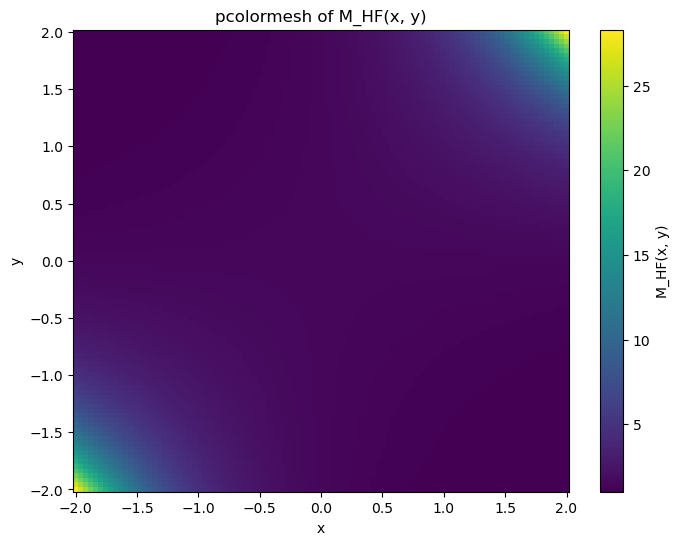

In [7]:
# Create the plot
plt.figure(figsize=(8, 6))
# shading='auto' is recommended for pcolormesh
mesh = plt.pcolormesh(X, Y, Z_HF.reshape(100,100), shading='auto', cmap='viridis')

# Add a colorbar and labels
plt.colorbar(mesh, label='M_HF(x, y)')
plt.title('pcolormesh of M_HF(x, y)')
plt.xlabel('x')
plt.ylabel('y')

# Display the plot
plt.show()

In [8]:
# Evaluate the function over the grid
Z_LF = M_LF(THETA)

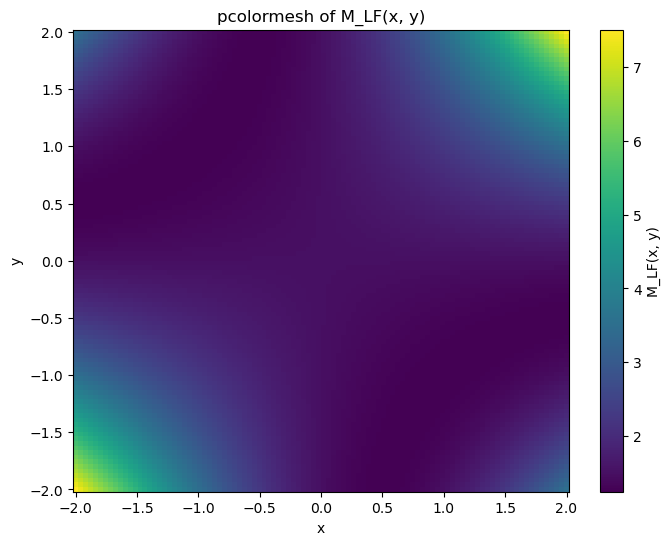

In [9]:
# Create the plot
plt.figure(figsize=(8, 6))
# shading='auto' is recommended for pcolormesh
mesh = plt.pcolormesh(X, Y, Z_LF.reshape(100,100), shading='auto', cmap='viridis')

# Add a colorbar and labels
plt.colorbar(mesh, label='M_LF(x, y)')
plt.title('pcolormesh of M_LF(x, y)')
plt.xlabel('x')
plt.ylabel('y')

# Display the plot
plt.show()

In [10]:
max(np.abs(Z_HF.reshape(100,100) - Z_LF.reshape(100,100)).flatten())

np.float64(20.799075016572118)

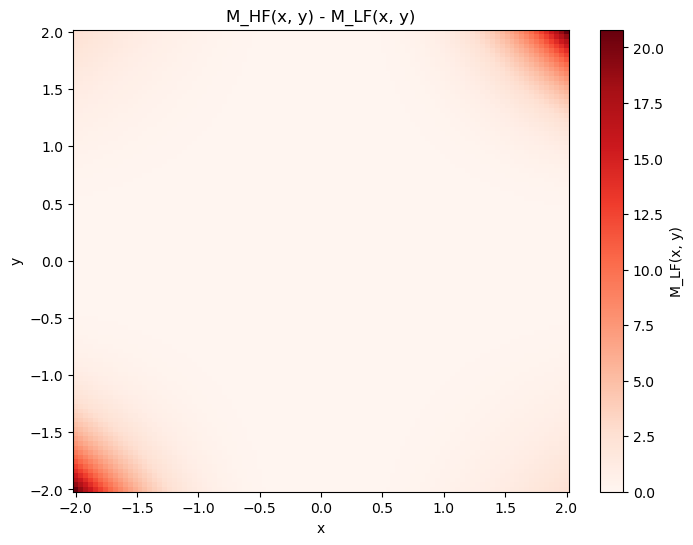

In [11]:
# Create the plot
plt.figure(figsize=(8, 6))
# shading='auto' is recommended for pcolormesh
mesh = plt.pcolormesh(X, Y, np.abs(Z_HF.reshape(100,100) - Z_LF.reshape(100,100)), shading='auto', cmap='Reds')

# Add a colorbar and labels
plt.colorbar(mesh, label='M_LF(x, y)')
plt.title('M_HF(x, y) - M_LF(x, y)')
plt.xlabel('x')
plt.ylabel('y')

# Display the plot
plt.show()

In [12]:
np.sqrt(np.sum(Z_HF ** 2)) * 0.001

np.float64(0.33573818975880093)

In [26]:
noise_st_dev = 2.5
meas_data = generate_noisy_data(THETA, noise_st_dev)

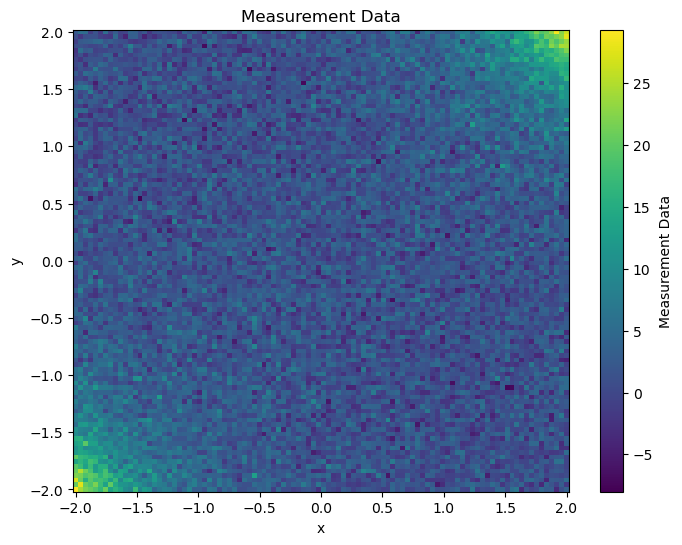

In [27]:
# Create the plot
plt.figure(figsize=(8, 6))
# shading='auto' is recommended for pcolormesh
mesh = plt.pcolormesh(X, Y, meas_data.reshape(100,100), shading='auto', cmap='viridis')

# Add a colorbar and labels
plt.colorbar(mesh, label='Measurement Data')
plt.title('Measurement Data')
plt.xlabel('x')
plt.ylabel('y')

# Display the plot
plt.show()

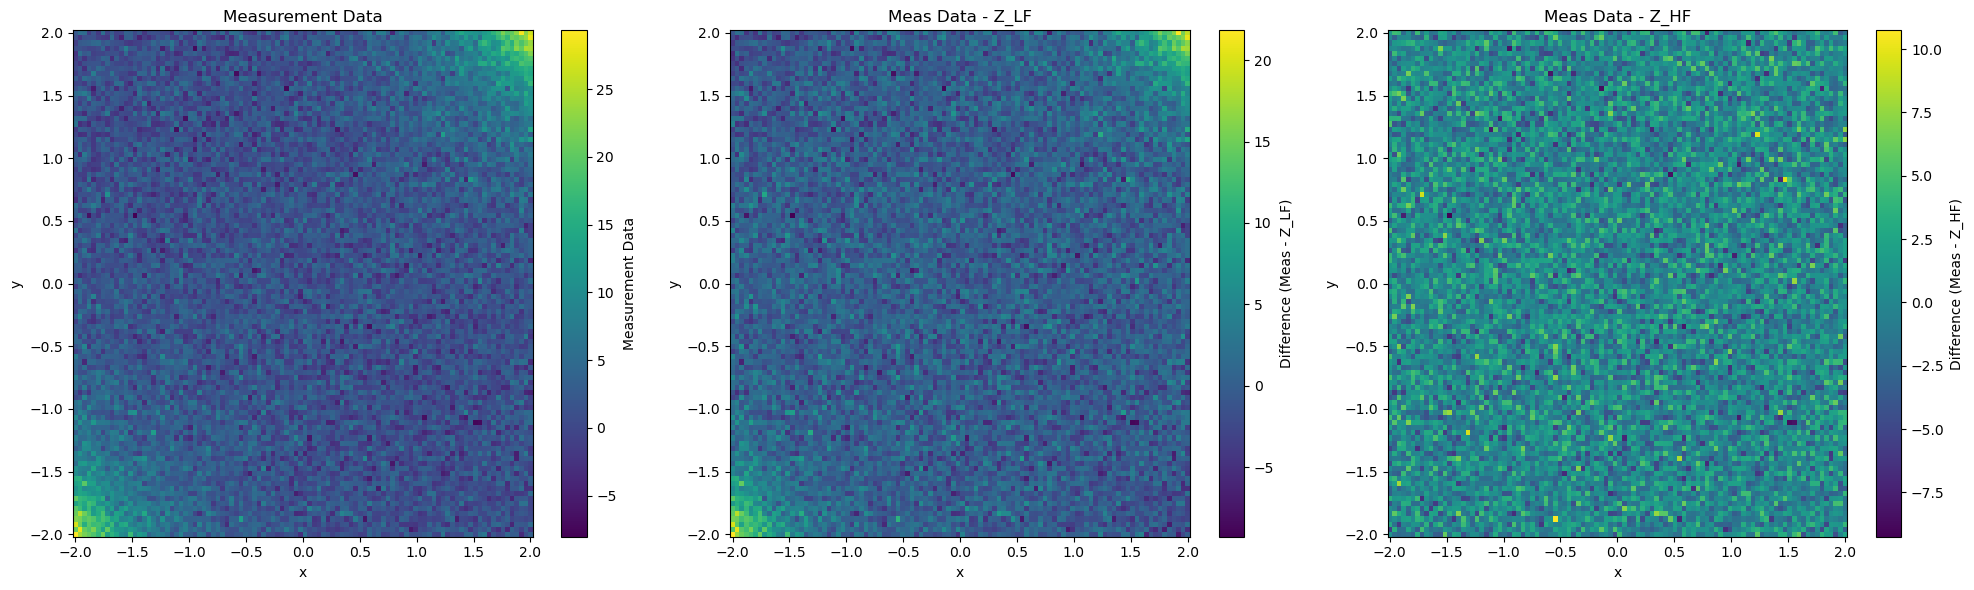

In [28]:
# Create a 1 by 3 subplot figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Measurement Data ---
mesh1 = axes[0].pcolormesh(X, Y, meas_data.reshape(100, 100), shading='auto', cmap='viridis')
fig.colorbar(mesh1, ax=axes[0], label='Measurement Data')
axes[0].set_title('Measurement Data')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# --- Plot 2: Measurement Data vs Z_LF (Low-Fidelity) ---
# Note: You can change 'viridis' to 'coolwarm' for a better visual of positive/negative residuals
diff_LF = (meas_data - Z_LF).reshape(100, 100)
mesh2 = axes[1].pcolormesh(X, Y, diff_LF, shading='auto', cmap='viridis')
fig.colorbar(mesh2, ax=axes[1], label='Difference (Meas - Z_LF)')
axes[1].set_title('Meas Data - Z_LF')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

# --- Plot 3: Measurement Data vs Z_HF (High-Fidelity) ---
diff_HF = (meas_data - Z_HF).reshape(100, 100)
mesh3 = axes[2].pcolormesh(X, Y, diff_HF, shading='auto', cmap='viridis')
fig.colorbar(mesh3, ax=axes[2], label='Difference (Meas - Z_HF)')
axes[2].set_title('Meas Data - Z_HF')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')

# Adjust layout so subplots don't overlap
plt.tight_layout()

# Display the plot
plt.show()